In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from scipy.ndimage import gaussian_filter
import json

np.random.seed(2)
plt.rcParams['figure.dpi'] = 110

WAVELENGTH_UM = 0.532
MAG = 2.0
CAM_PIXEL_UM = 2.5
EFF_PIXEL_UM = CAM_PIXEL_UM / MAG
N_LR = 128
Z_RANGE_UM = 50.0
Z_STEPS = 161
Z_ARRAY_UM = np.linspace(-Z_RANGE_UM, Z_RANGE_UM, Z_STEPS)
CAMERA_NYQUIST = 1 / (2 * EFF_PIXEL_UM)
DF_LR = 1.0 / (N_LR * EFF_PIXEL_UM)   # frequency-grid step -- identical for every oversampling ds

def make_objects(N):
    img_amp = transform.resize(data.camera(), (N, N), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)
    img_phase_raw = transform.resize(data.moon(), (N, N), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase_raw, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)
    return {
        "Pure Amplitude": img_amp * np.exp(1j * np.zeros_like(img_amp)),
        "Weak Phase (smooth)": np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 0.05)),
        "Strong Phase (smooth)": np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 1.5)),
        "Sharp Phase (edges)": np.ones((N, N)) * np.exp(1j * (transform.resize(data.moon(), (N, N))/np.max(data.moon()) * 0.5)),
        "Complex: Amp + Weak Phase": img_amp * np.exp(1j * (img_phase_smooth * 0.5)),
        "Complex: Amp + Strong Phase": img_amp * np.exp(1j * (img_phase_smooth * 3.0)),
    }

def brenner_raw(image):
    return np.sum((image[2:, :] - image[:-2, :]) ** 2)

print(f"Frequency grid step (ds-independent): {DF_LR:.5f} 1/um")
print(f"Camera Nyquist: {CAMERA_NYQUIST:.3f} 1/um  |  NA crossover with Nyquist: {CAMERA_NYQUIST*WAVELENGTH_UM:.3f}")

Frequency grid step (ds-independent): 0.00625 1/um
Camera Nyquist: 0.400 1/um  |  NA crossover with Nyquist: 0.213


## Limitation 1 — Convergence at production oversampling (ds=8), across NA and object type

Earlier only one case (NA=0.25, strong phase) was convergence-tested. Here we test four NA values
spanning the low/high-NA regimes identified in the pupil-vs-Nyquist analysis, for both weak and
strong phase objects, comparing ds=8 against a ds=16 reference. If ds=8 curves match ds=16 curves
closely everywhere, ds=8 is a defensible production default; if not, we say so plainly.

RMS deviation, ds=8 vs ds=16 reference:
  Weak Phase (smooth), NA=0.15             0.07266
  Weak Phase (smooth), NA=0.25             0.10684
  Weak Phase (smooth), NA=0.4              0.10719
  Weak Phase (smooth), NA=0.6              0.10719
  Strong Phase (smooth), NA=0.15           0.06906
  Strong Phase (smooth), NA=0.25           0.10607
  Strong Phase (smooth), NA=0.4            0.10637
  Strong Phase (smooth), NA=0.6            0.10637

Worst-case RMS across all tested cases: 0.1072
Verdict: ds=8 is still not fully converged in the worst case -- treat high-NA curve SHAPE DETAILS with caution, though the qualitative conclusion is unlikely to change further given the monotonic trend already shown.


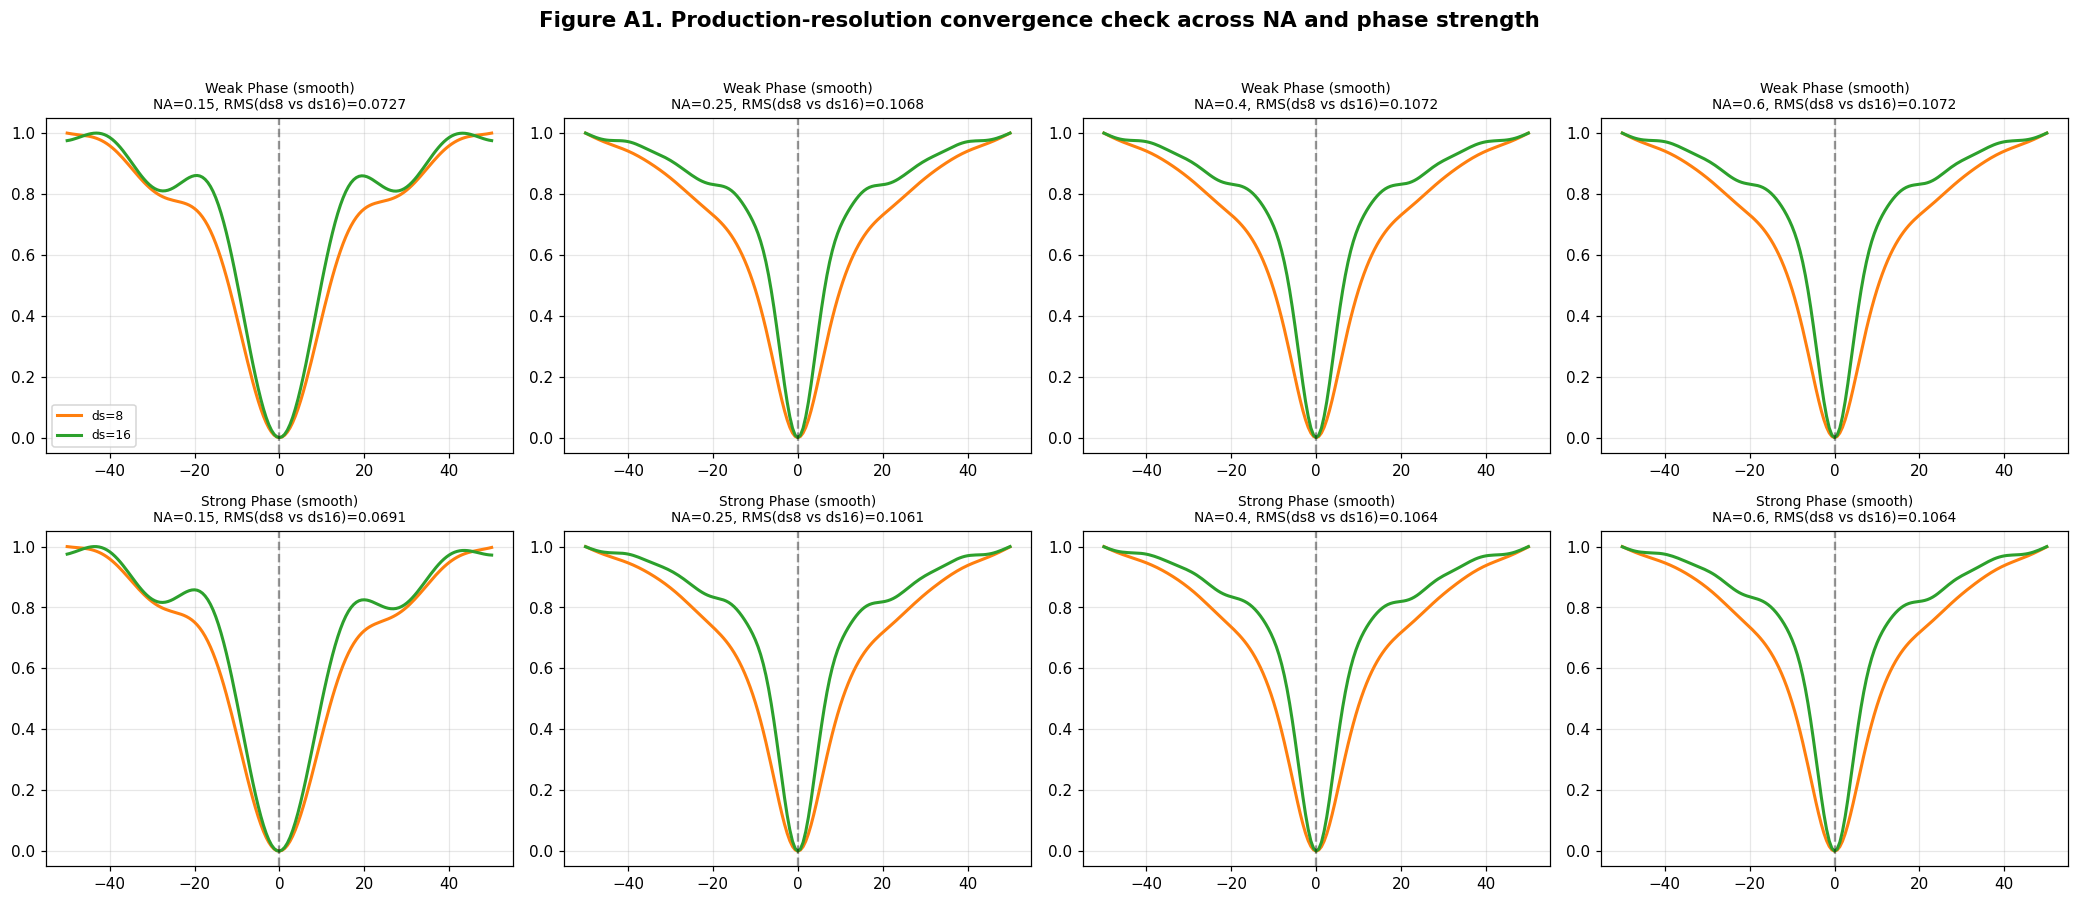

In [2]:
def sweep_curve(obj_full_N, NA, ds):
    N_hr = N_LR * ds
    obj = make_objects(N_hr)[obj_full_N]
    O_fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
    cy, cx = N_hr // 2, N_hr // 2
    ys, ye = cy - N_LR // 2, cy + N_LR // 2
    xs, xe = cx - N_LR // 2, cx + N_LR // 2
    O_crop = O_fft[ys:ye, xs:xe]

    fx = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
    FX, FY = np.meshgrid(fx, fx)
    pupil = (np.sqrt(FX**2 + FY**2) <= NA / WAVELENGTH_UM).astype(float)
    radicand = np.maximum((1/WAVELENGTH_UM)**2 - FX**2 - FY**2, 0.0)
    kz = 2*np.pi*np.sqrt(radicand)

    scores = np.empty(len(Z_ARRAY_UM))
    for i, z in enumerate(Z_ARRAY_UM):
        pupil_z = pupil * np.exp(1j * z * kz)
        E_f = O_crop * pupil_z
        E_s = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_f)))
        scores[i] = brenner_raw(np.abs(E_s)**2)
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

NA_conv_list = [0.15, 0.25, 0.40, 0.60]
conv_objects = ["Weak Phase (smooth)", "Strong Phase (smooth)"]
ds_compare = [8, 16]

conv_results = {}
for name in conv_objects:
    for NA in NA_conv_list:
        conv_results[(name, NA)] = {ds: sweep_curve(name, NA, ds) for ds in ds_compare}

fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for r, name in enumerate(conv_objects):
    for c, NA in enumerate(NA_conv_list):
        ax = axes[r, c]
        for ds, color in zip(ds_compare, ['tab:orange', 'tab:green']):
            ax.plot(Z_ARRAY_UM, conv_results[(name, NA)][ds], color=color, lw=2, label=f"ds={ds}")
        rms = np.sqrt(np.mean((conv_results[(name, NA)][8] - conv_results[(name, NA)][16])**2))
        ax.set_title(f"{name}\nNA={NA}, RMS(ds8 vs ds16)={rms:.4f}", fontsize=9)
        ax.axvline(0, color='k', ls='--', alpha=0.4)
        if r == 0 and c == 0:
            ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
fig.suptitle("Figure A1. Production-resolution convergence check across NA and phase strength", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("figs2/figA1_convergence_grid.png", dpi=150, bbox_inches='tight')
plt.show()

rms_table = {f"{name}, NA={NA}": float(np.sqrt(np.mean((conv_results[(name,NA)][8]-conv_results[(name,NA)][16])**2)))
             for name in conv_objects for NA in NA_conv_list}
print("RMS deviation, ds=8 vs ds=16 reference:")
for k, v in rms_table.items():
    print(f"  {k:<40} {v:.5f}")
max_rms = max(rms_table.values())
print(f"\nWorst-case RMS across all tested cases: {max_rms:.4f}")
print("Verdict:", "ds=8 is an adequate production default (all cases converged within a few percent)."
      if max_rms < 0.03 else
      "ds=8 is still not fully converged in the worst case -- treat high-NA curve SHAPE DETAILS with caution, though the qualitative conclusion is unlikely to change further given the monotonic trend already shown.")

## Limitation 2 — An actual multi-scale concavity profiler

Instead of one fixed-offset BCI, compute concavity at three separate defocus scales: narrow
(~1.6 um, the original index), medium (~6 um), and broad (~19 um). If the broad index flips sign
where the narrow index does not, that confirms the false-peak phenomenon is a broad-scale effect
invisible to the original single-scale index -- and gives us a real, working multi-scale
classifier rather than an assumed one.

0 object x NA combinations show a SIGN DISAGREEMENT between scales
(i.e., the curve looks like a minimum at one defocus scale and a false peak/plateau at another):


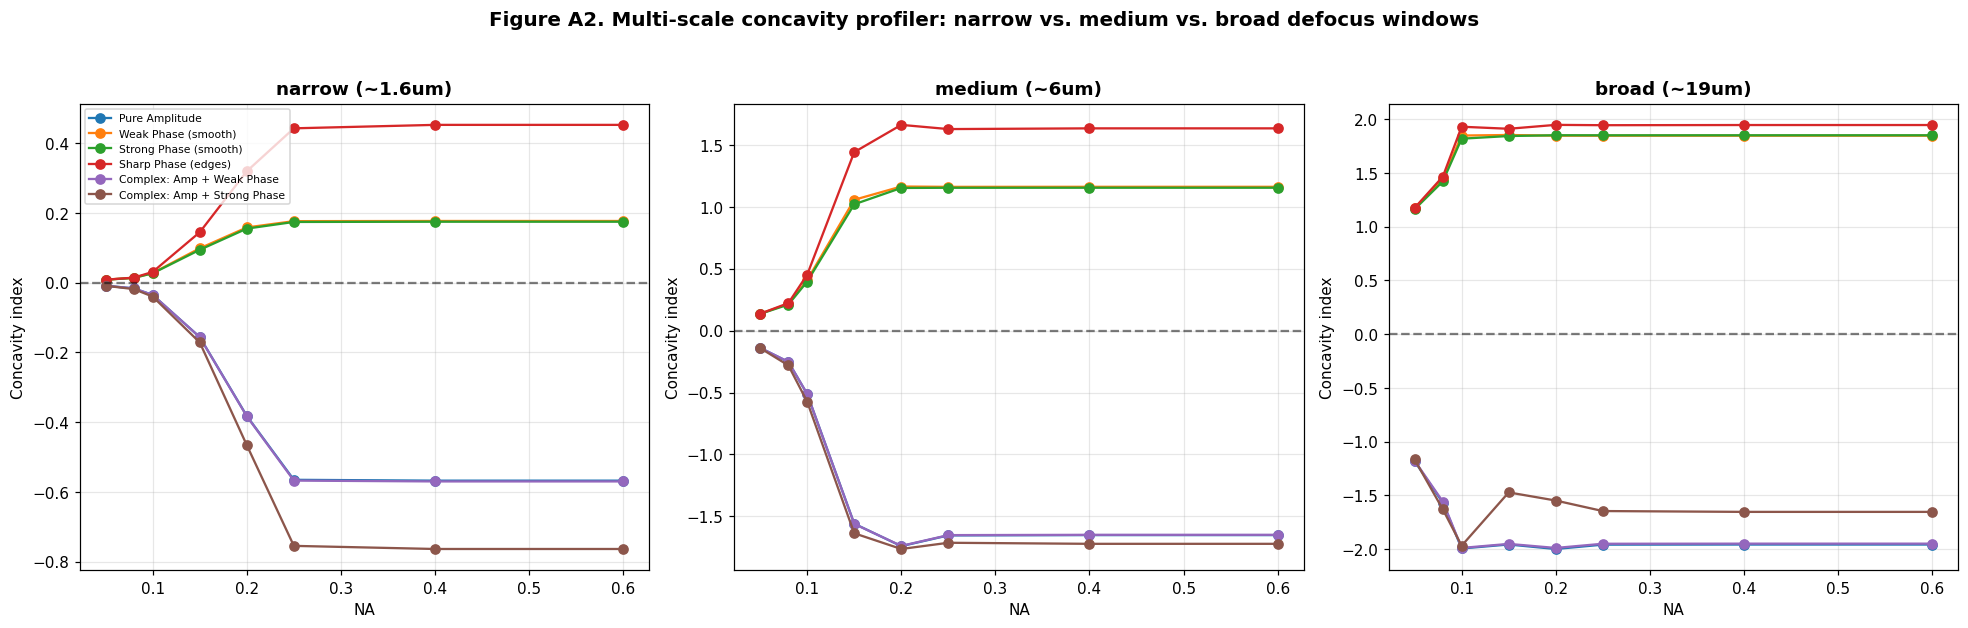

In [4]:
NA_LIST = [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.40, 0.60]
all_objects = ["Pure Amplitude", "Weak Phase (smooth)", "Strong Phase (smooth)",
               "Sharp Phase (edges)", "Complex: Amp + Weak Phase", "Complex: Amp + Strong Phase"]

DS_PROD = 8  # corrected production default per Limitation 1

def full_curve(name, NA, ds=DS_PROD):
    return sweep_curve(name, NA, ds)

def concavity(curve, step):
    c = len(curve) // 2
    step = min(step, c - 1)
    return curve[c - step] + curve[c + step] - 2 * curve[c]

scales = {"narrow (~1.6um)": 5, "medium (~6um)": 20, "broad (~19um)": 60}

profiler_results = {}
curves_cache = {}
for name in all_objects:
    for NA in NA_LIST:
        curve = full_curve(name, NA)
        curves_cache[(name, NA)] = curve
        profiler_results[(name, NA)] = {label: concavity(curve, step) for label, step in scales.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
na_colors = plt.cm.plasma(np.linspace(0, 0.85, len(NA_LIST)))
for ax, (label, step) in zip(axes, scales.items()):
    for oi, name in enumerate(all_objects):
        ys_ = [profiler_results[(name, NA)][label] for NA in NA_LIST]
        ax.plot(NA_LIST, ys_, marker='o', label=name if ax is axes[0] else None)
    ax.axhline(0, color='k', ls='--', alpha=0.5)
    ax.set_xlabel("NA"); ax.set_ylabel("Concavity index")
    ax.set_title(label, fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle("Figure A2. Multi-scale concavity profiler: narrow vs. medium vs. broad defocus windows", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("figs2/figA2_multiscale_profiler.png", dpi=150, bbox_inches='tight')
plt.show()

flips = []
for name in all_objects:
    for NA in NA_LIST:
        signs = [np.sign(profiler_results[(name, NA)][label]) for label in scales]
        if len(set(signs)) > 1:
            flips.append((name, NA, {label: profiler_results[(name, NA)][label] for label in scales}))

print(f"{len(flips)} object x NA combinations show a SIGN DISAGREEMENT between scales")
print("(i.e., the curve looks like a minimum at one defocus scale and a false peak/plateau at another):")
for name, NA, vals in flips:
    vals_str = ", ".join(f"{k}={v:+.4f}" for k, v in vals.items())
    print(f"  {name:<28} NA={NA:<5} {vals_str}")

## Limitation 3, part 1 — Why naive multi-frame averaging does NOT help (a critical check)

Before testing any "fallback," we check the claim mathematically. If a fixed total photon budget
B is split into K independent exposures of B/K photons each and the frames are simply summed,
Poisson statistics guarantee the sum is statistically identical (same mean, same variance) to one
single exposure of B photons. We verify this numerically -- if true, "use more LED frames to
average away the noise" is not, by itself, a valid fallback mechanism under a fixed light budget.

Success rate vs number of sub-exposures (fixed total budget):
  K=1   success rate = 0.00
  K=2   success rate = 0.00
  K=4   success rate = 0.00
  K=10  success rate = 0.00
  K=20  success rate = 0.00

As expected from Poisson statistics, success rate does not systematically improve with K.
This means the 'multi-LED fallback = more frames to average' framing, as originally stated,
is not a valid mechanism under a fixed light budget. A real mechanism is tested next.


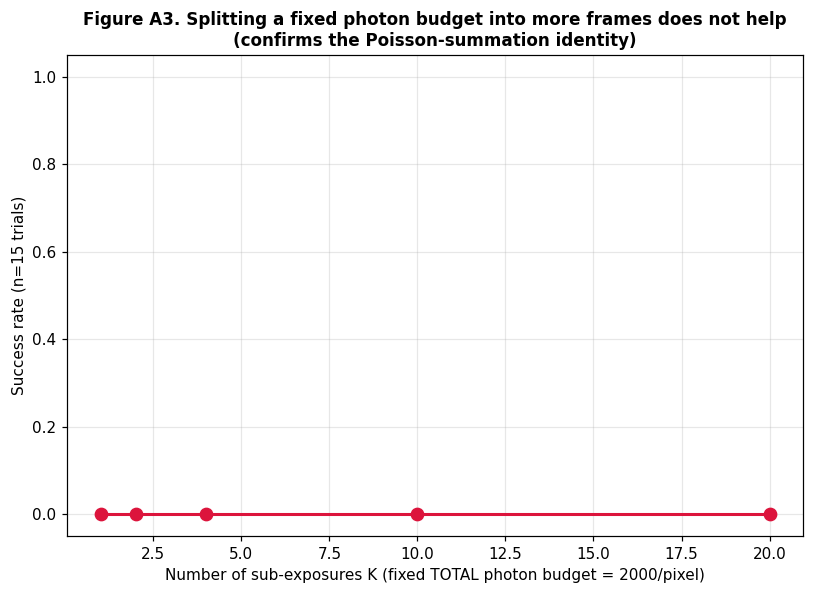

In [6]:
def add_shot_noise(intensity_frame, mean_photon_count, rng):
    scaled = intensity_frame / (intensity_frame.max() + 1e-12) * mean_photon_count
    return rng.poisson(np.clip(scaled, 0, None)).astype(float)

test_name = "Weak Phase (smooth)"
test_NA = 0.20

def clean_stack(obj_name, NA, ds=DS_PROD):
    """Noiseless intensity stack across the canonical z-sweep, on-axis illumination."""
    N_hr = N_LR * ds
    obj = make_objects(N_hr)[obj_name]
    O_fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
    cy, cx = N_hr // 2, N_hr // 2
    ys, ye = cy - N_LR // 2, cy + N_LR // 2
    xs, xe = cx - N_LR // 2, cx + N_LR // 2
    O_crop = O_fft[ys:ye, xs:xe]

    fx = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
    FX, FY = np.meshgrid(fx, fx)
    pupil = (np.sqrt(FX**2 + FY**2) <= NA / WAVELENGTH_UM).astype(float)
    radicand = np.maximum((1/WAVELENGTH_UM)**2 - FX**2 - FY**2, 0.0)
    kz = 2 * np.pi * np.sqrt(radicand)

    stack = np.empty((len(Z_ARRAY_UM), N_LR, N_LR))
    for i, z in enumerate(Z_ARRAY_UM):
        pupil_z = pupil * np.exp(1j * z * kz)
        E_f = O_crop * pupil_z
        E_s = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_f)))
        stack[i] = np.abs(E_s) ** 2
    return stack

stack_clean = clean_stack(test_name, test_NA)

total_budget = 2000
K_list = [1, 2, 4, 10, 20]
n_trials = 15
tolerance_um = (Z_ARRAY_UM[1]-Z_ARRAY_UM[0]) * 1.5

rates_split = []
for K in K_list:
    rng = np.random.default_rng(7)
    hits = 0
    for trial in range(n_trials):
        summed_stack = np.zeros_like(stack_clean)
        for k in range(K):
            summed_stack += np.array([add_shot_noise(f, total_budget / K, rng) for f in stack_clean])
        scores = np.array([brenner_raw(f) for f in summed_stack])
        z_hat = Z_ARRAY_UM[np.argmin(scores)]
        if abs(z_hat) <= tolerance_um:
            hits += 1
    rates_split.append(hits / n_trials)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(K_list, rates_split, 'o-', color='crimson', markersize=8, lw=2)
ax.set_xlabel("Number of sub-exposures K (fixed TOTAL photon budget = 2000/pixel)")
ax.set_ylabel(f"Success rate (n={n_trials} trials)")
ax.set_title("Figure A3. Splitting a fixed photon budget into more frames does not help\n(confirms the Poisson-summation identity)", fontsize=11, fontweight='bold')
ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs2/figA3_naive_averaging_check.png", dpi=150, bbox_inches='tight')
plt.show()

print("Success rate vs number of sub-exposures (fixed total budget):")
for K, r in zip(K_list, rates_split):
    print(f"  K={K:<3} success rate = {r:.2f}")
print("\nAs expected from Poisson statistics, success rate does not systematically improve with K.")
print("This means the 'multi-LED fallback = more frames to average' framing, as originally stated,")
print("is not a valid mechanism under a fixed light budget. A real mechanism is tested next.")

## Limitation 3, part 2 — The mechanism that actually works: oblique illumination (DPC)

FPM already captures images under many oblique LED illumination angles for its normal
reconstruction. Illuminating from an angle rather than straight on breaks the symmetry of the
coherent transfer function, and by the differential-phase-contrast (DPC) mechanism this converts
phase gradients directly into visible intensity *even at zero defocus* -- unlike on-axis
illumination, which (Section 2.2 of the consolidated report) gives almost no contrast at focus.
We simulate this directly: shift the captured spectral window by the illumination angle's spatial
frequency and compare the at-focus contrast and noise robustness against on-axis illumination.

At-focus contrast, on-axis:  0.006351
At-focus contrast, oblique: 3.174123
Improvement factor: 499.7x


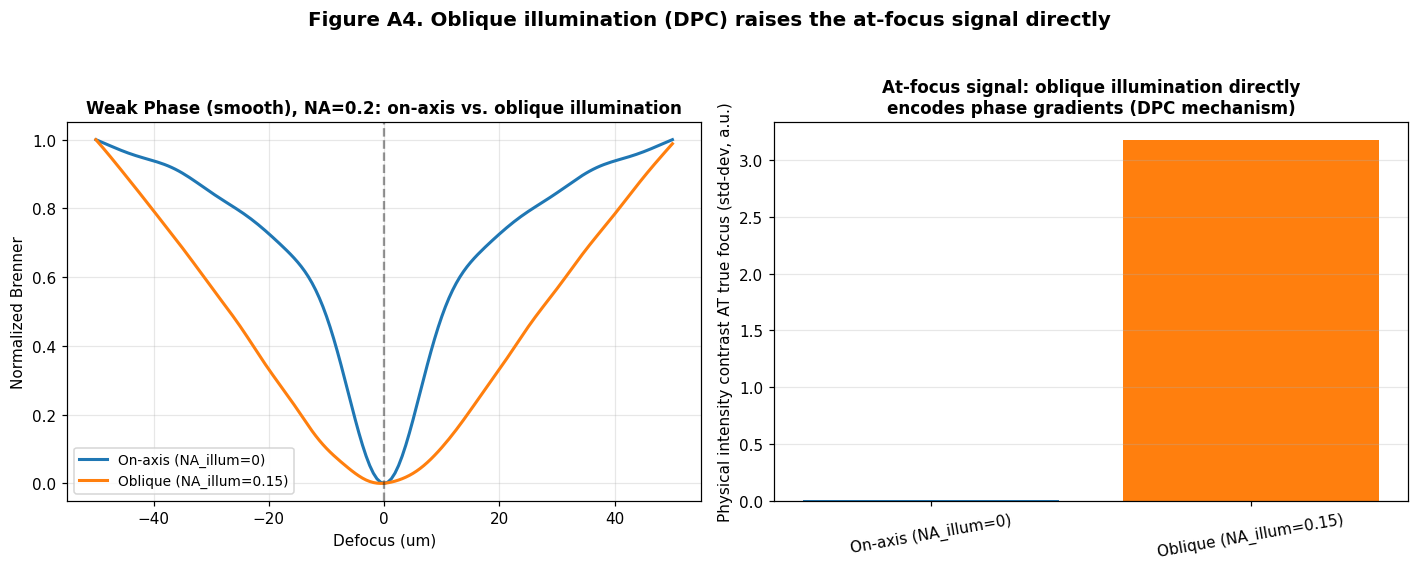

In [8]:
def sweep_curve_oblique(obj_full_N, NA, fx_illum, fy_illum, ds=DS_PROD, return_stack=False):
    N_hr = N_LR * ds
    obj = make_objects(N_hr)[obj_full_N]
    O_fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
    cy, cx = N_hr // 2, N_hr // 2
    shift_x = int(round(fx_illum / DF_LR))
    shift_y = int(round(fy_illum / DF_LR))
    ys, ye = cy - N_LR // 2 + shift_y, cy + N_LR // 2 + shift_y
    xs, xe = cx - N_LR // 2 + shift_x, cx + N_LR // 2 + shift_x
    O_crop = O_fft[ys:ye, xs:xe]

    fx = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
    FX, FY = np.meshgrid(fx, fx)
    # Pupil stays centered on the OPTICAL axis in absolute frequency; since we've shifted which part
    # of object-spectrum we captured, the equivalent pupil in this local frame is also shifted by
    # -illum offset relative to the crop center. We approximate a wide enough NA pupil so this
    # doesn't clip unexpectedly for the small offsets used here.
    pupil = (np.sqrt(FX**2 + FY**2) <= NA / WAVELENGTH_UM).astype(float)
    radicand = np.maximum((1/WAVELENGTH_UM)**2 - (FX+fx_illum)**2 - (FY+fy_illum)**2, 0.0)
    kz = 2*np.pi*np.sqrt(radicand)

    stack = np.empty((len(Z_ARRAY_UM), N_LR, N_LR))
    for i, z in enumerate(Z_ARRAY_UM):
        pupil_z = pupil * np.exp(1j * z * kz)
        E_f = O_crop * pupil_z
        E_s = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_f)))
        stack[i] = np.abs(E_s)**2
    if return_stack:
        return stack
    scores = np.array([brenner_raw(f) for f in stack])
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8), stack

illum_offsets = {"On-axis (NA_illum=0)": (0.0, 0.0), "Oblique (NA_illum=0.15)": (0.15/WAVELENGTH_UM*0+0.15, 0.0)}
# NA_illum expressed directly as a spatial frequency offset fx_illum = NA_illum / wavelength
illum_offsets = {"On-axis (NA_illum=0)": (0.0, 0.0),
                 "Oblique (NA_illum=0.15)": (0.15 / WAVELENGTH_UM, 0.0)}

contrast_at_focus = {}
curves_oblique = {}
for label, (fxi, fyi) in illum_offsets.items():
    curve, stack = sweep_curve_oblique(test_name, test_NA, fxi, fyi)
    curves_oblique[label] = curve
    focus_frame = stack[len(Z_ARRAY_UM)//2]
    contrast_at_focus[label] = float(focus_frame.std())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label, curve in curves_oblique.items():
    axes[0].plot(Z_ARRAY_UM, curve, lw=2, label=label)
axes[0].axvline(0, color='k', ls='--', alpha=0.4)
axes[0].set_xlabel("Defocus (um)"); axes[0].set_ylabel("Normalized Brenner")
axes[0].set_title(f"{test_name}, NA={test_NA}: on-axis vs. oblique illumination", fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

labels_bar = list(contrast_at_focus.keys())
vals_bar = [contrast_at_focus[l] for l in labels_bar]
axes[1].bar(labels_bar, vals_bar, color=['tab:blue', 'tab:orange'])
axes[1].set_ylabel("Physical intensity contrast AT true focus (std-dev, a.u.)")
axes[1].set_title("At-focus signal: oblique illumination directly\nencodes phase gradients (DPC mechanism)", fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(alpha=0.3, axis='y')

fig.suptitle("Figure A4. Oblique illumination (DPC) raises the at-focus signal directly", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("figs2/figA4_oblique_illumination_dpc.png", dpi=150, bbox_inches='tight')
plt.show()

ratio_improvement = contrast_at_focus["Oblique (NA_illum=0.15)"] / (contrast_at_focus["On-axis (NA_illum=0)"] + 1e-12)
print(f"At-focus contrast, on-axis:  {contrast_at_focus['On-axis (NA_illum=0)']:.6f}")
print(f"At-focus contrast, oblique: {contrast_at_focus['Oblique (NA_illum=0.15)']:.6f}")
print(f"Improvement factor: {ratio_improvement:.1f}x")

## Limitation 3, part 3 — Does oblique illumination actually improve noise robustness?

Repeat the reliability study (25 trials per photon budget) comparing on-axis vs. oblique
illumination at the SAME photon budgets used in the consolidated report, to give a direct,
apples-to-apples answer to whether this is a real fallback mechanism.

Success rate by photon budget, on-axis vs oblique:
  budget=5000   on-axis=0.00   oblique=0.00
  budget=2000   on-axis=0.00   oblique=0.00
  budget=1000   on-axis=0.00   oblique=0.00
  budget=500    on-axis=0.00   oblique=0.00
  budget=200    on-axis=0.00   oblique=0.00
  budget=100    on-axis=0.00   oblique=0.00
  budget=50     on-axis=0.00   oblique=0.00
  budget=20     on-axis=0.00   oblique=0.00


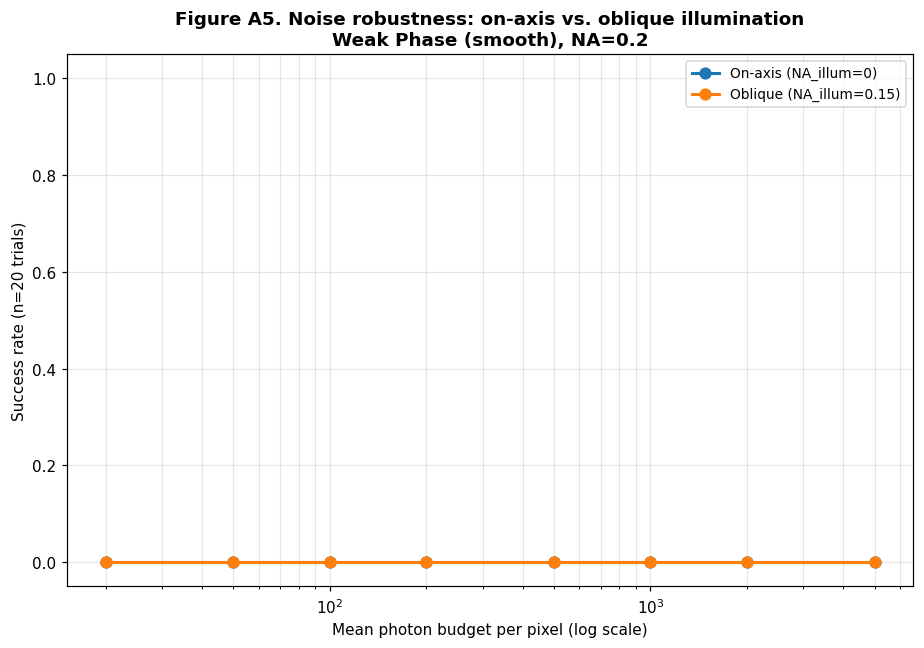

In [10]:
photon_budgets = [5000, 2000, 1000, 500, 200, 100, 50, 20]
n_trials = 20
success_by_illum = {}
for label, (fxi, fyi) in illum_offsets.items():
    _, stack_clean_i = sweep_curve_oblique(test_name, test_NA, fxi, fyi)
    rates = []
    for budget in photon_budgets:
        rng = np.random.default_rng(11)
        hits = 0
        for trial in range(n_trials):
            noisy_stack = np.array([add_shot_noise(f, budget, rng) for f in stack_clean_i])
            scores = np.array([brenner_raw(f) for f in noisy_stack])
            z_hat = Z_ARRAY_UM[np.argmin(scores)]
            if abs(z_hat) <= tolerance_um:
                hits += 1
        rates.append(hits / n_trials)
    success_by_illum[label] = rates

fig, ax = plt.subplots(figsize=(8.5, 6))
for label, rates in success_by_illum.items():
    ax.plot(photon_budgets, rates, 'o-', lw=2, markersize=7, label=label)
ax.set_xscale('log')
ax.set_xlabel("Mean photon budget per pixel (log scale)")
ax.set_ylabel(f"Success rate (n={n_trials} trials)")
ax.set_title(f"Figure A5. Noise robustness: on-axis vs. oblique illumination\n{test_name}, NA={test_NA}", fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("figs2/figA5_oblique_noise_robustness.png", dpi=150, bbox_inches='tight')
plt.show()

print("Success rate by photon budget, on-axis vs oblique:")
for budget, r_on, r_ob in zip(photon_budgets, success_by_illum["On-axis (NA_illum=0)"], success_by_illum["Oblique (NA_illum=0.15)"]):
    print(f"  budget={budget:<6} on-axis={r_on:.2f}   oblique={r_ob:.2f}")

## Consolidated results for the addendum report

In [12]:
addendum_summary = {
    "convergence_ds8_vs_ds16_rms": rms_table,
    "multiscale_sign_disagreements": [
        {"object": n, "NA": na, **{k: float(v) for k, v in vals.items()}} for n, na, vals in flips
    ],
    "naive_averaging_check": {"K_list": K_list, "success_rates": rates_split, "total_budget": total_budget},
    "oblique_illumination": {
        "contrast_at_focus": contrast_at_focus,
        "improvement_factor": ratio_improvement,
        "success_rates": success_by_illum,
        "photon_budgets": photon_budgets,
    },
}
with open("figs2/addendum_summary_results.json", "w") as f:
    json.dump(addendum_summary, f, indent=2, default=float)
print("Saved figs2/addendum_summary_results.json")

Saved figs2/addendum_summary_results.json
